# find the w, b and support vectors
### Install cvxopt-1.3.2
pip install cvxopt

Here we show how to find the w, b and also the support vectors using python package cvxopt

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Input data
X = np.array([
    [1, 7], [2, 8], [3, 8],       # Class +1
    [5, 1], [6, -1], [7, 3], [5, -2]  # Class -1
], dtype=np.float64)
y = np.array([1, 1, 1, -1, -1, -1, -1], dtype=np.float64)


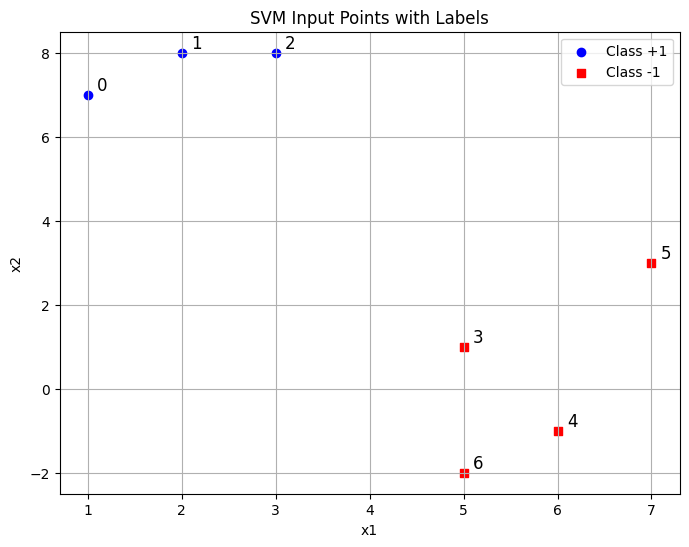

In [8]:
# Plotting
plt.figure(figsize=(8, 6))

plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='blue', marker='o', label='Class +1')
plt.scatter(X[y==-1][:, 0], X[y==-1][:, 1], color='red', marker='s', label='Class -1')

# Annotate points with labels
for i, (x1, x2) in enumerate(X):
    plt.text(x1 + 0.1, x2 + 0.1, f"{i}", fontsize=12, color='black')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('SVM Input Points with Labels')
plt.legend()
plt.grid(True)
plt.show()


In [9]:
from cvxopt import matrix, solvers

n_samples, n_features = X.shape

# 2. Compute the Gram matrix (kernel)
K = np.dot(X, X.T)
P = matrix(np.outer(y, y) * K)
q = matrix(-np.ones(n_samples))

# 3. Inequality constraints (α ≥ 0)
G = matrix(-np.eye(n_samples))
h = matrix(np.zeros(n_samples))

# 4. Equality constraint (sum α_i y_i = 0)
A = matrix(y.reshape(1, -1))
b = matrix(np.zeros(1))

# 5. Solve QP problem using cvxopt
solvers.options['show_progress'] = False  # Optional: hide solver output
solution = solvers.qp(P, q, G, h, A, b)
alphas = np.ravel(solution['x'])

# 6. Support vectors have α > 1e-5
sv = alphas > 1e-5
alpha_sv = alphas[sv]
X_sv = X[sv]
y_sv = y[sv]

# 7. Compute w
w = np.sum(alpha_sv[:, None] * y_sv[:, None] * X_sv, axis=0)

# 8. Compute b using any support vector (take mean over all for stability)
b_vals = y_sv - np.dot(X_sv, w)
b = np.mean(b_vals)

# 9. Print everything
print("Alphas:\n", alphas)
print("\nSupport Vectors:\n", X_sv)
print("\nWeights (w):", w)
print("Bias (b):", b)

# 10. Test classification
def predict(x):
    return np.sign(np.dot(w, x) + b)

print("\nPredictions:")
for i, xi in enumerate(X):
    print(f"Point {xi} => Predicted: {predict(xi)}, Actual: {y[i]}")


Alphas:
 [1.95065919e-10 3.33152447e-10 4.87804874e-02 8.40968653e-10
 1.75231202e-10 4.87804867e-02 1.91523417e-10]

Support Vectors:
 [[3. 8.]
 [7. 3.]]

Weights (w): [-0.19512194  0.24390244]
Bias (b): -0.36585369063492074

Predictions:
Point [1. 7.] => Predicted: 1.0, Actual: 1.0
Point [2. 8.] => Predicted: 1.0, Actual: 1.0
Point [3. 8.] => Predicted: 1.0, Actual: 1.0
Point [5. 1.] => Predicted: -1.0, Actual: -1.0
Point [ 6. -1.] => Predicted: -1.0, Actual: -1.0
Point [7. 3.] => Predicted: -1.0, Actual: -1.0
Point [ 5. -2.] => Predicted: -1.0, Actual: -1.0


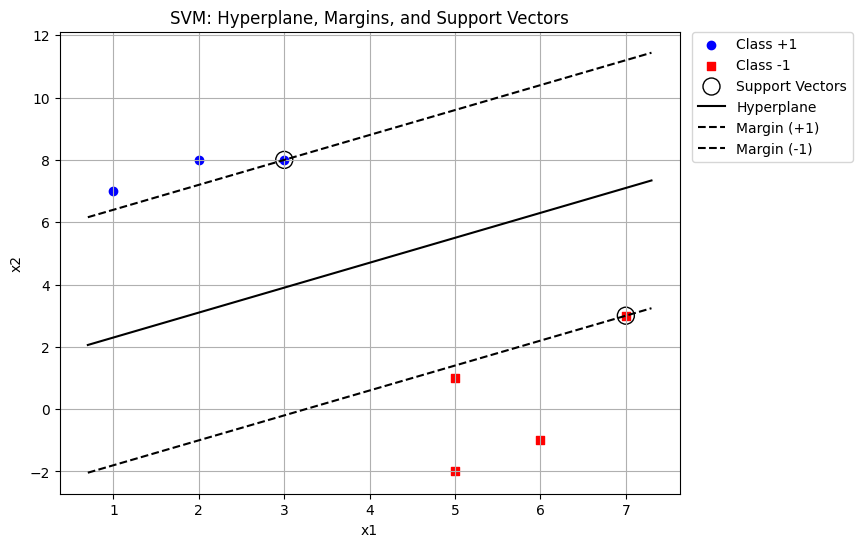

In [10]:
# Create a mesh to plot the decision boundary
def plot_svm(w, b, X, y, support_vectors):
    plt.figure(figsize=(8, 6))

    # Plot all data points
    for i in range(len(X)):
        if y[i] == 1:
            plt.scatter(X[i, 0], X[i, 1], c='b', marker='o', label='Class +1' if i == 0 else "")
        else:
            plt.scatter(X[i, 0], X[i, 1], c='r', marker='s', label='Class -1' if i == 3 else "")

    # Plot support vectors
    plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=150, facecolors='none', edgecolors='k', label='Support Vectors')

    # Plot decision boundary and margins
    ax = plt.gca()
    x_vals = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 200)
    y_vals = -(w[0] * x_vals + b) / w[1]
    y_margin_pos = -(w[0] * x_vals + b - 1) / w[1]
    y_margin_neg = -(w[0] * x_vals + b + 1) / w[1]

    plt.plot(x_vals, y_vals, 'k-', label='Hyperplane')
    plt.plot(x_vals, y_margin_pos, 'k--', label='Margin (+1)')
    plt.plot(x_vals, y_margin_neg, 'k--', label='Margin (-1)')

    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
    plt.title("SVM: Hyperplane, Margins, and Support Vectors")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True)
    plt.show()

# Call the plot function
plot_svm(w, b, X, y, X_sv)


# Another simple example:

In [15]:
import numpy as np
from sklearn.svm import SVC

X = np.array([
    [1, 2],
    [2, 1],
    [2, 3],
    [3, 2],
    [6, 6],
    [7, 7],
    [8, 6]
])

# Labels (0 or 1) for above data
y = np.array([0, 0, 0, 0, 1, 1, 1])

model = SVC(kernel='linear')
model.fit(X, y)

data = np.array([[2,2], [8,4]])
print("prediction:", model.predict(data))

prediction: [0 1]


Weights (w): [[0.2856 0.2856]]
Bias (b): [-2.42773333]
Support Vectors : [[2. 3.]
 [3. 2.]
 [6. 6.]]


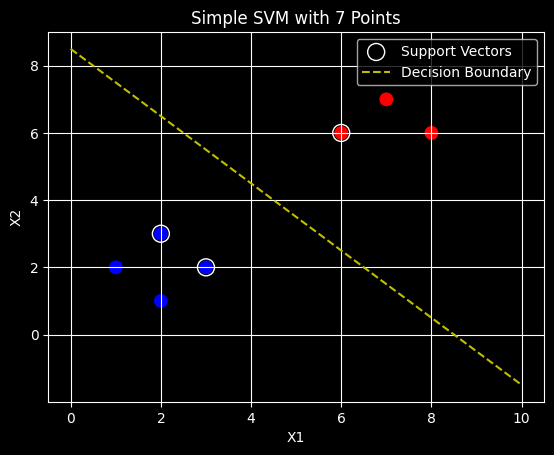

In [17]:
import matplotlib.pyplot as plt

print("Weights (w):", model.coef_)
print("Bias (b):", model.intercept_)
print("Support Vectors :", model.support_vectors_)

# Plot the points and decision boundary
plt.style.use('dark_background')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=80)

# Plot support vectors
sv = model.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=150, facecolors='none', edgecolors='white', label="Support Vectors")

# Create line for decision boundary
w = model.coef_[0]
b = model.intercept_[0]

# x-values for the line
x_vals = np.linspace(0, 10, 100)
y_vals = -(w[0] * x_vals + b) / w[1]

plt.plot(x_vals, y_vals, 'y--', label="Decision Boundary")

plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.title("Simple SVM with 7 Points")
plt.grid(True)
plt.show()
